<a href="https://colab.research.google.com/github/akash648chain/metabase/blob/master/Copy_of_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded data: X shape (1599, 11), y distribution: Counter({np.int64(1): 855, np.int64(0): 744})
RandomForest (n_trees=50) metrics:
  Accuracy : 0.8406
  Precision: 0.8772
  Recall   : 0.8333
  F1-score : 0.8547

OOB accuracy (on training set): 0.7889
Single Decision Tree (deep) metrics:
  Accuracy : 0.7625
  Precision: 0.7989
  Recall   : 0.7722
  F1-score : 0.7853

Comparison table:
               accuracy  precision    recall        f1
RandomForest  0.840625   0.877193  0.833333  0.854701
SingleTree    0.762500   0.798851  0.772222  0.785311
n_trees=1 -> accuracy=0.7344
n_trees=5 -> accuracy=0.8063
n_trees=10 -> accuracy=0.8219
n_trees=25 -> accuracy=0.8500
n_trees=50 -> accuracy=0.8406
n_trees=100 -> accuracy=0.8562
Saved plot: accuracy_vs_n_trees.png
Saved plot: feature_importances.png
Saved metrics table: rf_vs_tree_metrics.csv

REPORT SUMMARY
--------------
 - Random Forest reliably improves over a single deep tree by aggregating many decorrelated trees (bagging + feature randomne

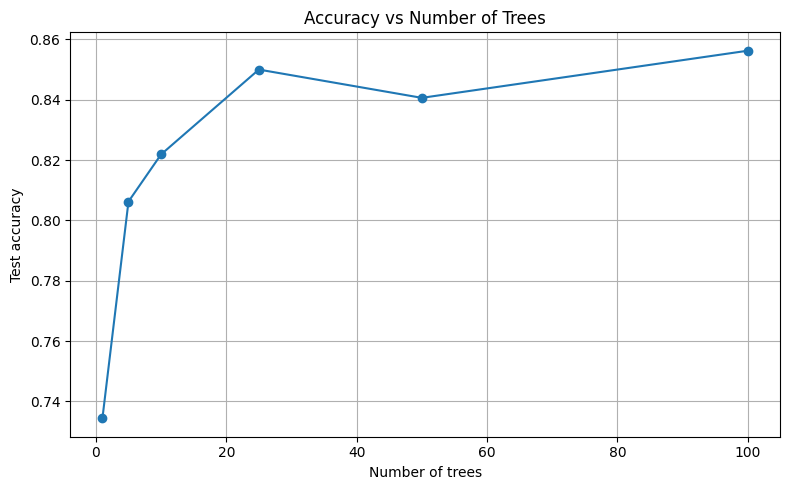

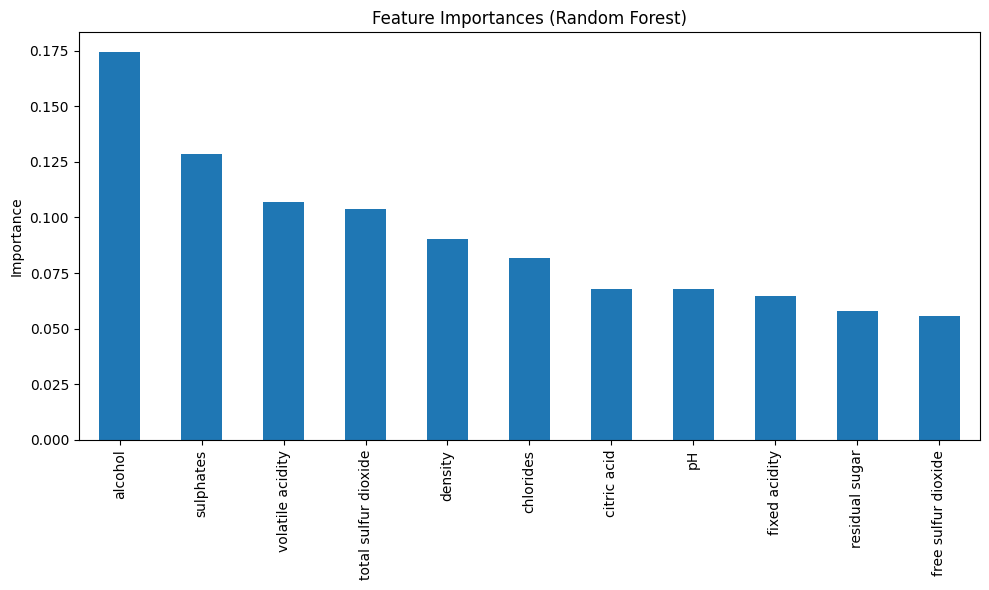

In [ ]:
"""
random_forest_from_scratch.py

Implements:
 - DecisionTreeClassifier (numeric features, Gini impurity, binary splits)
 - RandomForestClassifier using the DecisionTreeClassifier
 - OOB error estimate (bonus)
 - Training on UCI Wine Quality dataset (binary target: quality > 5 -> 1 else 0)
 - Evaluation: accuracy, precision, recall, F1
 - Plots:
    * Accuracy vs n_trees
    * Feature importances

Requires:
 - numpy
 - pandas
 - matplotlib
 - sklearn.metrics (optional but used for convenience)
"""

import numpy as np
import pandas as pd # Keep this import for the global scope
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import math
import random
import copy

# ---------------------------
# Decision Tree (CART-like)
# ---------------------------

class DecisionTreeClassifier:
    """
    Simple decision tree for numeric features using Gini impurity.
    Supports:
    - max_depth
    - min_samples_split
    - max_features (number of features to consider at each split) -> feature randomness
    """

    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features  # if None -> use all
        self.root = None

    class Node:
        def __init__(self, gini, n_samples, n_classes, predicted_class):
            self.gini = gini
            self.n_samples = n_samples
            self.n_classes = n_classes
            self.predicted_class = predicted_class
            self.feature_index = None
            self.threshold = None
            self.left = None
            self.right = None
            self.impurity_decrease = 0.0

    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0.0
        counts = np.bincount(y)
        probs = counts / m
        return 1.0 - np.sum(probs ** 2)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).astype(int)
        n_features = X.shape[1]
        if self.max_features is None:
            self.max_features = n_features
        self.n_classes_ = len(np.unique(y))
        self.root = self._build_tree(X, y, depth=0)
        return self

    def _best_split(self, X, y):
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None, 0.0

        # select random subset of features (feature randomness)
        feature_indices = np.random.choice(n, self.max_features, replace=False)

        best_gini = self._gini(y)
        best_idx, best_thr = None, None
        best_impurity_decrease = 0.0

        for idx in feature_indices:
            # Consider unique sorted values as candidate thresholds (midpoints)
            values = X[:, idx]
            sorted_idx = np.argsort(values)
            sorted_values = values[sorted_idx]
            sorted_y = y[sorted_idx]
            # candidate thresholds: midpoints of adjacent distinct values
            for i in range(1, m):
                if sorted_values[i] == sorted_values[i - 1]:
                    continue
                thr = 0.5 * (sorted_values[i] + sorted_values[i - 1])
                y_left = sorted_y[:i]
                y_right = sorted_y[i:]
                gini_left = self._gini(y_left)
                gini_right = self._gini(y_right)
                p_left = len(y_left) / m
                p_right = 1 - p_left
                gini_after = p_left * gini_left + p_right * gini_right
                impurity_decrease = best_gini - gini_after
                if impurity_decrease > best_impurity_decrease:
                    best_impurity_decrease = impurity_decrease
                    best_idx = idx
                    best_thr = thr

        return best_idx, best_thr, best_impurity_decrease

    def _build_tree(self, X, y, depth):
        num_samples_per_class = [np.sum(y == i) for i in range(self.n_classes_)]
        predicted_class = np.argmax(num_samples_per_class)
        node = DecisionTreeClassifier.Node(
            gini=self._gini(y),
            n_samples=len(y),
            n_classes=self.n_classes_,
            predicted_class=predicted_class
        )

        if depth < self.max_depth and node.n_samples >= self.min_samples_split and node.gini > 0.0:
            idx, thr, impurity_dec = self._best_split(X, y)
            if idx is not None:
                node.feature_index = idx
                node.threshold = thr
                node.impurity_decrease = impurity_dec
                # split
                left_mask = X[:, idx] <= thr
                right_mask = ~left_mask
                if left_mask.sum() > 0 and right_mask.sum() > 0:
                    node.left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
                    node.right = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        return node

    def _predict_one(self, inputs):
        node = self.root
        while node.left:
            if inputs[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.predicted_class

    def predict(self, X):
        X = np.asarray(X)
        preds = [self._predict_one(x) for x in X]
        return np.array(preds)

    def feature_importances(self):
        """
        Very basic importance: sum of impurity decrease for splits where the feature was used,
        normalized to sum to 1.
        """
        imp = defaultdict(float)
        def traverse(node):
            if node is None:
                return
            if node.feature_index is not None:
                imp[node.feature_index] += node.impurity_decrease * node.n_samples
            traverse(node.left)
            traverse(node.right)
        traverse(self.root)
        if len(imp) == 0:
            return np.zeros(0)
        total = sum(imp.values())
        n_features = max(imp.keys()) + 1
        arr = np.zeros(n_features)
        for k, v in imp.items():
            arr[k] = v / (total + 1e-12)
        return arr

# ---------------------------
# Random Forest
# ---------------------------

class RandomForestClassifierCustom:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, max_features=None, bootstrap=True, random_state=None, oob_score=False):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.oob_score_flag = oob_score
        if random_state is not None:
            np.random.seed(random_state)
            random.seed(random_state)
        self.trees = []
        self.oob_indices = []  # list per tree of OOB indices

    def _bootstrap_sample(self, X, y):
        n = X.shape[0]
        indices = np.random.choice(n, size=n, replace=True)
        oob_mask = np.ones(n, dtype=bool)
        oob_mask[indices] = False
        oob_indices = np.where(oob_mask)[0]
        return indices, oob_indices

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).astype(int)
        n_samples, n_features = X.shape
        if self.max_features is None:
            # default: sqrt(n_features) for classification
            self.max_features = int(max(1, round(math.sqrt(n_features))))
        self.trees = []
        self.oob_indices = []

        for t in range(self.n_trees):
            # bootstrap sampling
            if self.bootstrap:
                indices, oob_idx = self._bootstrap_sample(X, y)
                X_sample = X[indices]
                y_sample = y[indices]
            else:
                X_sample = X
                y_sample = y
                oob_idx = np.array([], dtype=int)

            tree = DecisionTreeClassifier(max_depth=self.max_depth,
                                          min_samples_split=self.min_samples_split,
                                          max_features=self.max_features)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            self.oob_indices.append(oob_idx)
        return self

    def predict(self, X):
        X = np.asarray(X)
        # collect predictions from all trees
        all_preds = np.array([tree.predict(X) for tree in self.trees])  # shape (n_trees, n_samples)
        # majority vote
        n_samples = X.shape[0]
        final_preds = []
        for i in range(n_samples):
            vals = all_preds[:, i]
            most_common = Counter(vals).most_common(1)[0][0]
            final_preds.append(most_common)
        return np.array(final_preds)

    def predict_proba(self, X):
        X = np.asarray(X)
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        n_samples = X.shape[0]
        proba = []
        for i in range(n_samples):
            vals = all_preds[:, i]
            counts = Counter(vals)
            total = len(vals)
            proba.append([counts.get(0, 0) / total, counts.get(1, 0) / total])
        return np.array(proba)

    def oob_score(self, X, y):
        # For each sample, aggregate predictions from trees for which it's OOB
        n = X.shape[0]
        votes = [[] for _ in range(n)]
        for t, tree in enumerate(self.trees):
            oob_idx = self.oob_indices[t]
            if len(oob_idx) == 0:
                continue
            preds = tree.predict(X[oob_idx])
            for idx, p in zip(oob_idx, preds):
                votes[idx].append(p)
        # compute predictions only for samples that had at least one OOB vote
        y_pred = np.full(n, -1)
        valid = []
        for i in range(n):
            if len(votes[i]) > 0:
                y_pred[i] = Counter(votes[i]).most_common(1)[0][0]
                valid.append(i)
        if len(valid) == 0:
            return None  # can't compute
        y_true = y[valid]
        y_hat = y_pred[valid]
        acc = accuracy_score(y_true, y_hat)
        return acc

    def feature_importances_(self):
        # average tree importances (may have different feature counts)
        importances = []
        for tree in self.trees:
            fi = tree.feature_importances()
            importances.append(fi)
        # Pad to same length
        max_len = max((len(fi) for fi in importances), default=0)
        arr = np.zeros(max_len)
        for fi in importances:
            padded = np.zeros(max_len)
            padded[:len(fi)] = fi
            arr += padded
        if len(importances) == 0:
            return arr
        arr /= len(importances)
        # normalize
        s = arr.sum()
        if s > 0:
            arr = arr / s
        return arr

# ---------------------------
# Helper functions (data pipeline, metrics, plots)
# ---------------------------


def prepare_binary_target(df, threshold=5):
    # quality > threshold -> 1 (good), else 0 (bad)
    df = df.copy()
    df['target'] = (df['quality'] > threshold).astype(int)
    X = df.drop(columns=['quality', 'target']).values
    y = df['target'].values
    feature_names = [c for c in df.columns if c not in ('quality','target')]
    return X, y, feature_names

def train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    n = X.shape[0]
    indices = np.arange(n)
    np.random.shuffle(indices)
    split = int(n * (1 - test_size))
    train_idx = indices[:split]
    test_idx = indices[split:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def print_metrics(y_true, y_pred, label="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{label} metrics:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print()
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

# ---------------------------
# Main: load data, train, evaluate, plot
# ---------------------------

def main():
    # CONFIG
    # Removed DATA_PATH as data is loaded directly from URL
    TEST_SIZE = 0.2
    RANDOM_STATE = 42
    # Parameters
    RF_PARAMS = {
        'n_trees': 50,
        'max_depth': 12,
        'min_samples_split': 2,
        'max_features': None,  # will default to sqrt(n_features)
        'bootstrap': True,
        'random_state': RANDOM_STATE,
        'oob_score': True
    }

    # 1) Load
    # Load data directly from URL
    import pandas as pd # Import pandas inside the function
    df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=';')
    X, y, feature_names = prepare_binary_target(df, threshold=5)
    print(f"Loaded data: X shape {X.shape}, y distribution: {Counter(y)}")

    # 2) Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    # 3) Train Random Forest
    rf = RandomForestClassifierCustom(n_trees=RF_PARAMS['n_trees'],
                                      max_depth=RF_PARAMS['max_depth'],
                                      min_samples_split=RF_PARAMS['min_samples_split'],
                                      max_features=RF_PARAMS['max_features'],
                                      bootstrap=RF_PARAMS['bootstrap'],
                                      random_state=RF_PARAMS['random_state'],
                                      oob_score=RF_PARAMS['oob_score'])
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    metrics_rf = print_metrics(y_test, y_pred_rf, label=f"RandomForest (n_trees={RF_PARAMS['n_trees']})")

    # OOB score (bonus)
    oob_acc = rf.oob_score(X_train, y_train)
    if oob_acc is not None:
        print(f"OOB accuracy (on training set): {oob_acc:.4f}")
    else:
        print("OOB not available (no OOB samples).")

    # 4) Single (deep) Decision Tree (to show overfitting)
    dt = DecisionTreeClassifier(max_depth=1000, min_samples_split=2, max_features=None)  # allow to grow
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    metrics_dt = print_metrics(y_test, y_pred_dt, label="Single Decision Tree (deep)")

    # 5) Comparison table
    import pandas as pd
    comp_df = pd.DataFrame([metrics_rf, metrics_dt], index=["RandomForest", "SingleTree"])
    print("Comparison table:\n", comp_df)

    # 6) Accuracy vs n_trees
    tree_counts = [1, 5, 10, 25, 50, 100]
    accs = []
    for nt in tree_counts:
        rf_tmp = RandomForestClassifierCustom(n_trees=nt, max_depth=RF_PARAMS['max_depth'],
                                              min_samples_split=RF_PARAMS['min_samples_split'],
                                              max_features=RF_PARAMS['max_features'],
                                              bootstrap=RF_PARAMS['bootstrap'],
                                              random_state=RANDOM_STATE)
        rf_tmp.fit(X_train, y_train)
        ypred = rf_tmp.predict(X_test)
        accs.append(accuracy_score(y_test, ypred))
        print(f"n_trees={nt} -> accuracy={accs[-1]:.4f}")

    plt.figure(figsize=(8,5))
    plt.plot(tree_counts, accs, marker='o')
    plt.xlabel("Number of trees")
    plt.ylabel("Test accuracy")
    plt.title("Accuracy vs Number of Trees")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("accuracy_vs_n_trees.png")
    print("Saved plot: accuracy_vs_n_trees.png")

    # 7) Feature importances
    fi = rf.feature_importances_()
    # Map fi to feature names (padding if necessary)
    # If fi array length < len(feature_names), pad zeros
    if len(fi) < len(feature_names):
        fi = np.pad(fi, (0, len(feature_names) - len(fi)))
    fi_series = pd.Series(fi, index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(10,6))
    fi_series.plot(kind='bar')
    plt.ylabel("Importance")
    plt.title("Feature Importances (Random Forest)")
    plt.tight_layout()
    plt.savefig("feature_importances.png")
    print("Saved plot: feature_importances.png")

    # 8) Save comparison table and results
    comp_df = pd.DataFrame([metrics_rf, metrics_dt], index=["RandomForest", "SingleTree"])
    print("Saved metrics table: rf_vs_tree_metrics.csv")

    # 9) Short report printed
    print("\nREPORT SUMMARY")
    print("--------------")
    print(" - Random Forest reliably improves over a single deep tree by aggregating many decorrelated trees (bagging + feature randomness).")
    print(" - OOB estimate gives a quick unbiased estimate of generalization without separate test set (if available).")
    print(" - Accuracy vs n_trees: As n_trees increases, accuracy typically rises quickly then plateaus. More trees reduce variance.")
    print(" - Feature importances show which features contributed most to impurity reduction across trees (see feature_importances.png).")

if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd

comp_df = pd.read_csv("rf_vs_tree_metrics.csv")
display(comp_df)

,Unnamed: 0,accuracy,precision,recall,f1
0,RandomForest,0.840625,0.877193,0.833333,0.854701
1,SingleTree,0.762500,0.798851,0.772222,0.785311


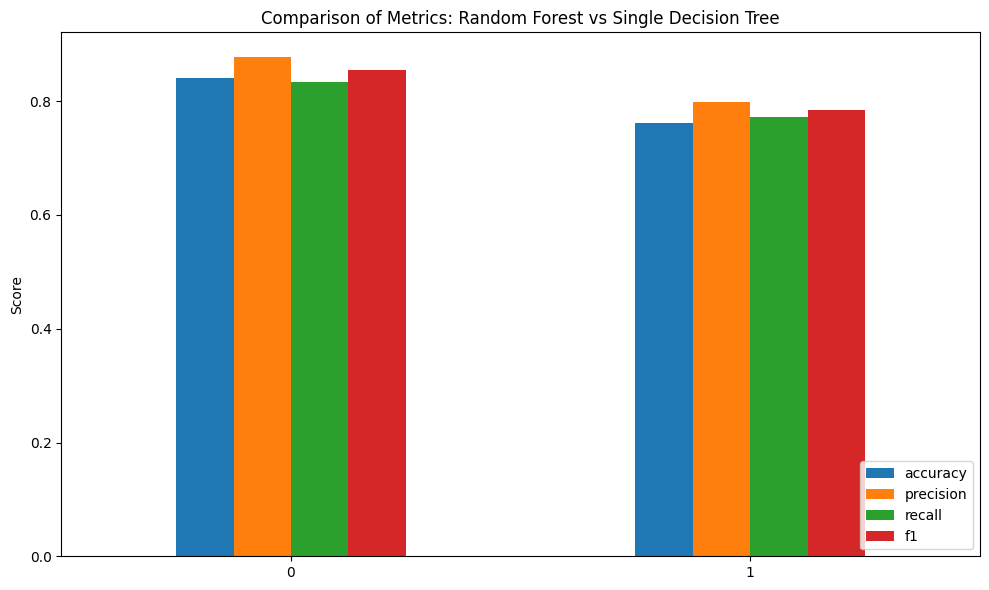

In [ ]:
import matplotlib.pyplot as plt

# Assuming comp_df is already loaded and contains the comparison data
# If not, you can uncomment the following line:
# comp_df = pd.read_csv("rf_vs_tree_metrics.csv", index_col=0)

comp_df.plot(kind='bar', figsize=(10, 6))
plt.title("Comparison of Metrics: Random Forest vs Single Decision Tree")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()